# 09 · Uncertainty Propagation Strategy — `pyhydra.uq`

**Author:** Salvador Navas
**Basin:** Río Besaya — Cantabria (Los Corrales de Buelna)

## What this notebook does

Notebooks 06-08 selected a **MaxDiss design of historical/synthetic events**,
ran each one through **HEC-RAS**, and used the results to map flood hazard
under present and future climate. That design was built to answer one
question: *do we have to simulate every synthetic event, or can a reduced
design plus a surrogate stand in for the rest?*

`pyhydra.uq` (pyhydra v0.2.0) answers that question from a measurement rather
than a convention. This notebook applies it, end to end, to the real Besaya
ensembles already on disk:

1. the **design** — `eventos_maxdiss.csv`, the events that were actually run
   through HEC-RAS (Notebook 06);
2. the **population** — `matriz_sintetica_maxdiss.csv`, the ~4,900-member
   synthetic catalogue the climate-change return-period mapping in Notebook 08
   must cover.

We turn the archived flood-depth rasters into scalar hazard metrics, measure
whether flooded area is *emulable* at this design size, cross-validate that
measurement, ask what a 30-point pilot would have concluded, reconstruct the
full population with `reduce_and_emulate`, and replay the sequential stopping
rule to see how much of the budget was actually needed.

**Scope, stated plainly, as `pyhydra.uq`'s own docs insist on:** this
validates three scalar summaries per raster -- flooded area, mean depth,
maximum depth -- not raster-by-raster reconstruction. The cross-validation
below is a flat (non-nested) K-fold, useful for a first read of the numbers;
the published, nested-CV headline figures for this exact case are in
`HYDRA-paper/papers/pyhydra_emulation_cg` (`analysis/s2b_besaya_surrogate_cv.py`),
alongside the peer-review history that got them there.


In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import os
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import KFold

from pyhydra.uq import (
    emulability,
    emulator_families,
    error_metrics,
    loo_error,
    maxdiss_order,
    pilot_design,
    reduce_and_emulate,
    select_strategy,
    sequential_design,
    voronoi_weights,
)

warnings.filterwarnings("ignore")
SEED = 20260803
rng = np.random.default_rng(SEED)
print("pyhydra.uq loaded")


pyhydra.uq loaded


## Paths

Same resolution order as the other `los_corrales_buelna` notebooks: an
`HYDRA_DATA_DIR` environment variable first, then the repo-local `data/`
folder, then the sibling `HYDRA/data` checkout used throughout development.
`DATA_ROOT` is the shared, read-only input tree (rasters, MaxDiss CSVs); the
raster-summary cache this notebook writes goes to a session-local
`generated/` folder instead, following the same isolation as Notebooks 01-08
-- `/workspace/data` is mounted read-only in the hosted HYDRA deployment.


In [2]:
_cwd = Path.cwd()
_candidates = [Path('/workspace'), _cwd, *_cwd.parents]
REPO_ROOT = next(
    (p for p in _candidates if (p / 'notebooks').exists() or (p / 'pyhydra').exists()),
    _cwd,
)


def _hydra_data_dir() -> Path:
    for c in (
        os.environ.get('HYDRA_DATA_DIR'),
        REPO_ROOT / 'data',
        REPO_ROOT.parent / 'HYDRA' / 'data',
        Path('~/Desktop/Github/HYDRA/data').expanduser(),
    ):
        if c is None:
            continue
        c = Path(c)
        if (c / 'pilot_cases' / 'los_corrales_buelna').exists():
            return c
    raise FileNotFoundError(
        "Could not locate the los_corrales_buelna pilot-case data. "
        "Set HYDRA_DATA_DIR to the HYDRA/data directory."
    )


DATA_DIR = _hydra_data_dir()
DATA_ROOT = DATA_DIR / 'pilot_cases' / 'los_corrales_buelna'
PROC_DIR = DATA_ROOT / 'processed'
RASTER_DIR = PROC_DIR / 'flood_maps' / 'simulations'


def _hydra_session_root() -> Path:
    env_root = os.environ.get('HYDRA_SESSION_DIR') or os.environ.get('HYDRA_RUNTIME_DIR')
    if env_root:
        return Path(env_root)
    cwd = Path.cwd().resolve()
    for p in (cwd, *cwd.parents):
        if p.name == 'notebooks':
            return p.parent
    return cwd / '.hydra_runtime'


SESSION_ROOT = _hydra_session_root()
SESSION_DATA_ROOT = SESSION_ROOT / 'data' / 'pilot_cases' / 'los_corrales_buelna'
GEN_DIR = SESSION_DATA_ROOT / 'generated'
GEN_DIR.mkdir(parents=True, exist_ok=True)

print('DATA_ROOT (shared, read-only):', DATA_ROOT)
print('GEN_DIR (session-local cache):', GEN_DIR)
print('rasters found:', len(list(RASTER_DIR.glob('Simul_*.tif'))))


DATA_ROOT (shared, read-only): /Users/salvadornavasfernandez/Desktop/Github/HYDRA/data/pilot_cases/los_corrales_buelna
GEN_DIR (session-local cache): /Users/salvadornavasfernandez/Desktop/Github/pyhydra/data/pilot_cases/los_corrales_buelna/generated
rasters found: 433


## The design and the population it must reconstruct

`FEATURES` matches the three continuous MaxDiss features used throughout the
Besaya notebooks: peak flow, mean flow and duration. `Tipo_Hidro` (hydrograph
shape) is categorical and is kept as metadata rather than fed to the design
reduction, following the same convention as the rest of this pilot case.


In [3]:
FEATURES = ["Qmax", "Qmed", "Duracion"]

design_events = pd.read_csv(PROC_DIR / "eventos_maxdiss.csv", index_col=0)
population = pd.read_csv(PROC_DIR / "matriz_sintetica_maxdiss.csv", index_col=0).dropna()

X_design_full = design_events[FEATURES].to_numpy(float)
X_population = population[FEATURES].to_numpy(float)

print(f"design (simulated):  {len(design_events):4d} events, columns {list(design_events.columns)}")
print(f"population (target): {len(population):4d} members")


design (simulated):   425 events, columns ['Qmax', 'Qmed', 'Duracion', 'Tipo_Hidro']
population (target): 4943 members


### The design deliberately oversamples the tail

A MaxDiss design is not a random sample of the population it stands in for.
That is *why* `pyhydra.uq.voronoi_weights` exists: reporting error unweighted,
over the design, silently favours the extreme events the design was built to
cover.


Qmax mean -- design: 151.1 m3/s, population: 83.3 m3/s


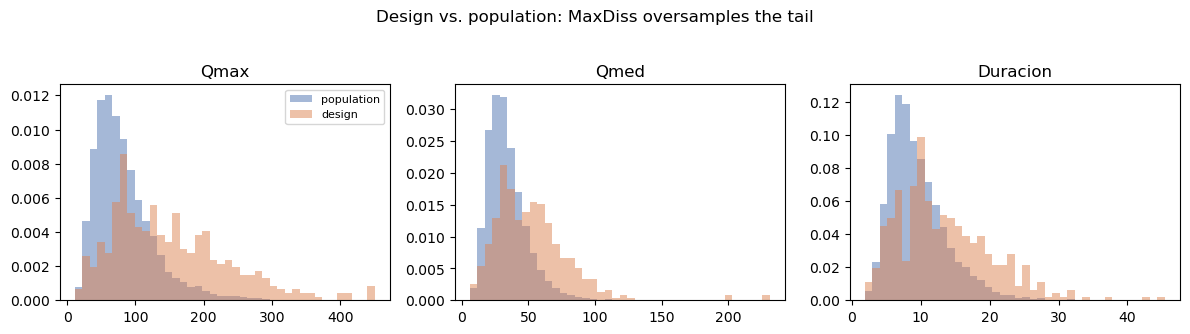

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.2))
for ax, col in zip(axes, FEATURES):
    ax.hist(population[col], bins=40, density=True, alpha=0.5, label="population", color="#4c72b0")
    ax.hist(design_events[col], bins=40, density=True, alpha=0.5, label="design", color="#dd8452")
    ax.set_title(col)
axes[0].legend(fontsize=8)
fig.suptitle("Design vs. population: MaxDiss oversamples the tail", y=1.03)
fig.tight_layout()

print("Qmax mean -- design: %.1f m3/s, population: %.1f m3/s"
      % (design_events.Qmax.mean(), population.Qmax.mean()))


## From flood-depth rasters to scalar hazard metrics

Each simulated event has an archived HEC-RAS depth raster
(`flood_maps/simulations/Simul_<id>.tif`). We reduce every raster to three
scalar summaries -- flooded area, mean depth, maximum depth over wet cells
(depth > 5 cm) -- the same definitions used in the published analysis. This
takes well under a minute at this raster count and is written once to a
manifest-free CSV under `generated/`, so re-running the notebook is instant.


In [5]:
import re

SUMMARY_CSV = GEN_DIR / "besaya_flood_map_summaries.csv"
WET_THRESHOLD = 0.05  # m


def summarise_raster(path: Path) -> dict:
    import rasterio

    with rasterio.open(path) as src:
        cell_area = abs(src.res[0] * src.res[1])
        arr = src.read(1)
        if src.nodata is not None:
            arr = np.where(arr == src.nodata, np.nan, arr)
    wet = arr > WET_THRESHOLD
    n_wet = int(np.count_nonzero(wet))
    depth = arr[wet]
    return {
        "simulation": int(re.fullmatch(r"Simul_(\d+)\.tif", path.name).group(1)),
        "flooded_area_ha": n_wet * cell_area / 1e4,
        "depth_mean_m": float(depth.mean()) if n_wet else 0.0,
        "depth_max_m": float(depth.max()) if n_wet else 0.0,
    }


if SUMMARY_CSV.exists():
    raster_summaries = pd.read_csv(SUMMARY_CSV, index_col="simulation")
    print(f"loaded cached summaries for {len(raster_summaries)} rasters from {SUMMARY_CSV}")
else:
    paths = sorted(
        (p for p in RASTER_DIR.glob("Simul_*.tif") if re.fullmatch(r"Simul_\d+\.tif", p.name)),
        key=lambda p: int(p.stem.split("_")[1]),
    )
    recs = []
    for i, p in enumerate(paths):
        recs.append(summarise_raster(p))
        if (i + 1) % 100 == 0:
            print(f"  {i + 1}/{len(paths)} rasters summarised")
    raster_summaries = (
        pd.DataFrame(recs).set_index("simulation").sort_index()
    )
    raster_summaries.to_csv(SUMMARY_CSV)
    print(f"summarised {len(raster_summaries)} rasters -> {SUMMARY_CSV}")

TARGETS = ["flooded_area_ha", "depth_mean_m", "depth_max_m"]


  100/425 rasters summarised


  200/425 rasters summarised


  300/425 rasters summarised


  400/425 rasters summarised


summarised 425 rasters -> /Users/salvadornavasfernandez/Desktop/Github/pyhydra/data/pilot_cases/los_corrales_buelna/generated/besaya_flood_map_summaries.csv


In [6]:
# Join design features to raster summaries on the shared simulation id.
events = design_events.join(raster_summaries, how="inner")
print(f"{len(design_events)} MaxDiss events, {len(raster_summaries)} archived rasters, "
      f"{len(events)} matched by simulation id")

X_design = events[FEATURES].to_numpy(float)
Y_design = events[TARGETS].to_numpy(float)
y_area = events["flooded_area_ha"].to_numpy(float)
events[["Qmax", "Qmed", "Duracion", *TARGETS]].describe()


425 MaxDiss events, 425 archived rasters, 425 matched by simulation id


,Qmax,Qmed,Duracion,flooded_area_ha,depth_mean_m,depth_max_m
count,425.000000,425.000000,425.000000,425.000000,425.000000,425.000000
mean,151.087464,52.213359,13.337809,88.199498,0.908330,4.846371
std,85.391522,28.316059,6.884511,41.394517,0.220584,0.738908
min,10.907000,5.848300,1.844200,21.965000,0.624829,3.712059
25%,83.268760,33.931134,8.617700,57.573700,0.804430,4.496010
50%,134.110000,47.585000,11.955000,85.367500,0.842485,4.764565
75%,203.080000,65.908000,17.375000,108.440600,0.910167,4.955910
max,450.940000,231.280000,45.456000,357.512100,2.631789,11.059555


## Voronoi population weights

Each design point is assigned the population members closest to it in
standardized feature space. A weight of zero is informative, not suppressed:
it means that design point represents nothing in this population.


In [7]:
w_pop = voronoi_weights(X_design, X_population)
print(f"design points: {len(X_design)}, weights sum to {w_pop.sum():.0f} "
      f"(population size {len(X_population)})")
print(f"weight min/median/max: {w_pop.min():.0f} / {np.median(w_pop):.0f} / {w_pop.max():.0f}")
print(f"design points representing zero population members: {(w_pop == 0).sum()}")


design points: 425, weights sum to 4943 (population size 4943)
weight min/median/max: 0 / 3 / 189
design points representing zero population members: 43


## Emulability: can flooded area be emulated at this design size?

`emulability()` is the pilot diagnostic *and* the family-selection step of the
surrogate that gets built -- deliberately the same procedure, so the number
below describes the model actually used later in this notebook.


In [8]:
e_diag = emulability(X_design, y_area, random_state=SEED)
print(e_diag)
print("\nper-family cross-validated R2:")
for name, score in e_diag.scores.items():
    print(f"  {name:10s} {score:+.3f}")


Emulability(r2=0.863, family='rbf_cubic', n_design=400, scheme='5-fold')

per-family cross-validated R2:
  rbf_cubic  +0.863
  rbf_linear +0.843
  knn_5      +0.830


## Cross-validated error, weighted and unweighted, against the classical baseline

A flat (non-nested) 10-fold cross-validation with the family `emulability`
selected above, compared against `baseline_peak_only` -- the conventional
practice of treating flood hazard as a function of peak flow alone. Every
error is reported twice: unweighted over the design, and weighted by how many
population members each design point's Voronoi cell represents.


In [9]:
def cv_predict(model, X, y, seed=SEED, folds=10):
    pred = np.empty(len(y))
    for tr, te in KFold(folds, shuffle=True, random_state=seed).split(X):
        pred[te] = model.fit(X[tr], y[tr]).predict(X[te])
    return pred


candidates = {
    e_diag.family: emulator_families((e_diag.family,))[e_diag.family],
    "baseline_peak_only": emulator_families(("baseline_peak_only",))["baseline_peak_only"],
}

rows = []
for name, model in candidates.items():
    pred = cv_predict(model, X_design, y_area)
    m_u = error_metrics(y_area, pred)
    m_w = error_metrics(y_area, pred, w_pop)
    rows.append({
        "model": name,
        "rmse_ha": round(m_u["rmse"], 2), "r2": round(m_u["r2"], 3),
        "rmse_ha_weighted": round(m_w["rmse"], 2), "r2_weighted": round(m_w["r2"], 3),
    })
cv_table = pd.DataFrame(rows)
cv_table


,model,rmse_ha,r2,rmse_ha_weighted,r2_weighted
0,rbf_cubic,15.53,0.859,12.55,0.751
1,baseline_peak_only,27.77,0.549,25.28,-0.012


## What a 30-point pilot would have concluded

`select_strategy` is meant to be called *before* the rest of the budget is
spent. Here the whole design is already simulated, so we can ask the
retrospective question directly: if the analysis had committed to only a
30-point pilot out of the design that was ultimately run, would the rule have
recommended reducing and emulating the rest?

`maxdiss_order` is greedy and therefore nested, so `pilot_design` reselects a
fresh MaxDiss ordering *within the 425 already-simulated events* -- the same
device the published analysis uses to turn an archived design into a
learning-curve / stopping-rule replay.


In [10]:
pilot = pilot_design(X_design, n_max=len(X_design), n_pilot=30)
X_pilot = X_design[pilot["pilot"]]
y_pilot = y_area[pilot["pilot"]]  # already simulated -- standing in for simulate()

decision = select_strategy(X_pilot, y_pilot, n_max=len(X_design), random_state=SEED)
print(decision)
print(f"\npilot size: {decision.n_pilot}, remaining budget under this decision: {decision.n_remaining}")
print(f"margin over threshold: {decision.margin:+.3f}  (marginal: {decision.is_marginal})")


StrategyDecision('reduce_and_emulate', R2=0.658 vs 0.50, margin=+0.158)

pilot size: 30, remaining budget under this decision: 395
margin over threshold: +0.158  (marginal: False)


## Reduce and emulate: reconstruct the climate-projection population

`reduce_and_emulate` keeps simulated values exactly and emulates the rest of
whatever array it is given. The design events are not literal rows of the
4,900-member population (they come from a separate, historically-anchored
catalogue), so we stack them ahead of the population and mark them as the
simulated indices -- the population rows are the ones actually reconstructed.


In [11]:
X_stack = np.vstack([X_design, X_population])
design_index = np.arange(len(X_design))

values, e_final = reduce_and_emulate(X_stack, design_index, y_area, random_state=SEED)
reconstructed_population = values[len(X_design):]

print(e_final)
print(f"\nreconstructed flooded area over the {len(X_population)}-member population:")
print(pd.Series(reconstructed_population).describe())


Emulability(r2=0.863, family='rbf_cubic', n_design=400, scheme='5-fold')

reconstructed flooded area over the 4943-member population:
count    4943.000000
mean       58.103630
std        21.555800
min        17.833394
25%        42.723498
50%        55.364921
75%        68.063035
max       353.161578
dtype: float64


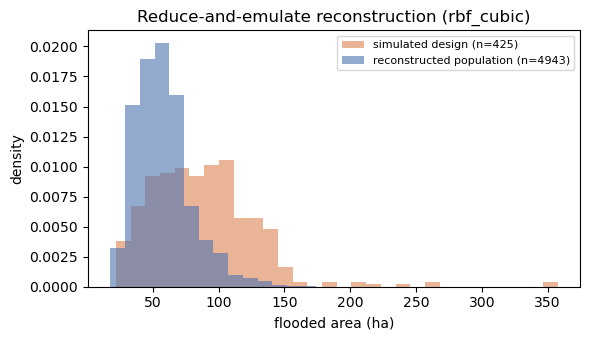

In [12]:
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.hist(y_area, bins=30, density=True, alpha=0.6, label=f"simulated design (n={len(y_area)})",
        color="#dd8452")
ax.hist(reconstructed_population, bins=30, density=True, alpha=0.6,
        label=f"reconstructed population (n={len(reconstructed_population)})", color="#4c72b0")
ax.set_xlabel("flooded area (ha)")
ax.set_ylabel("density")
ax.legend(fontsize=8)
ax.set_title(f"Reduce-and-emulate reconstruction ({e_final.family})")
fig.tight_layout()


## Sequential stopping: how much of the budget was actually needed?

`sequential_design` grows a MaxDiss design a few points at a time and tracks
leave-one-out error -- no extra solver runs, since it is computed on
evaluations already paid for -- classifying each increment as `improving`,
`converged` or `deteriorating`. Only a run of consecutive `converged`
increments stops it.

Because every point here was already simulated, `simulate()` below is a
lookup into the archived rasters, not a new HEC-RAS run -- this replays what
the rule would have seen in real time, without spending anything new.


In [13]:
_lookup = {tuple(row): val for row, val in zip(X_design, y_area)}


def simulate_lookup(X_subset):
    return np.array([_lookup[tuple(row)] for row in X_subset])


stop_unweighted = sequential_design(X_design, simulate_lookup, n_max=len(X_design))
stop_weighted = sequential_design(
    X_design, simulate_lookup, n_max=len(X_design), population=X_population
)

print(stop_unweighted)
print(stop_weighted)


StoppingResult(stopped_at=250, unstable_at=None, n_evaluations=250, weighted=False)
StoppingResult(stopped_at=375, unstable_at=None, n_evaluations=375, weighted=True)


,n,error,relative_improvement,state,converged_run
0,25,45.862336,NaN,initial,False
1,50,35.865463,0.217976,improving,False
2,75,30.497588,0.149667,improving,False
3,100,26.410337,0.134019,improving,False
4,125,23.577168,0.107275,improving,False
5,150,22.454606,0.047612,converged,False
6,175,20.861804,0.070934,improving,False
7,200,20.459947,0.019263,converged,False
8,225,19.711388,0.036587,converged,False
9,250,19.233241,0.024257,converged,True


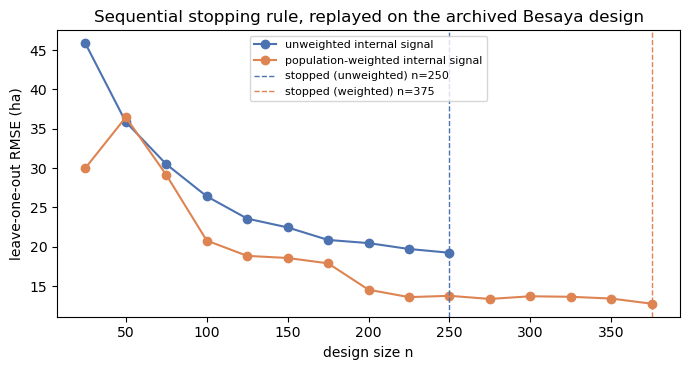

In [14]:
hist_u = stop_unweighted.to_frame()
hist_w = stop_weighted.to_frame()

fig, ax = plt.subplots(figsize=(7, 3.8))
ax.plot(hist_u.n, hist_u.error, "o-", color="#4c72b0", label="unweighted internal signal")
ax.plot(hist_w.n, hist_w.error, "o-", color="#dd8452", label="population-weighted internal signal")
if stop_unweighted.stopped_at is not None:
    ax.axvline(stop_unweighted.stopped_at, color="#4c72b0", ls="--", lw=1,
               label=f"stopped (unweighted) n={stop_unweighted.stopped_at}")
if stop_weighted.stopped_at is not None:
    ax.axvline(stop_weighted.stopped_at, color="#dd8452", ls="--", lw=1,
               label=f"stopped (weighted) n={stop_weighted.stopped_at}")
ax.set_xlabel("design size n")
ax.set_ylabel("leave-one-out RMSE (ha)")
ax.legend(fontsize=8)
ax.set_title("Sequential stopping rule, replayed on the archived Besaya design")
fig.tight_layout()

hist_u


If the weighted run above never reaches three consecutive `converged`
increments, that reproduces a documented finding of the module itself
(`pyhydra.uq.stopping`'s own docstring): Voronoi weights change as the design
grows, so the population-weighted signal is not monotone across steps and the
stopping rule does not currently transfer to it. That is a real, open
limitation, not a bug in this notebook -- see `out/stopping_rule.json` in the
paper's analysis for the same result on a slightly different replay protocol.

## Summary

- The Besaya design (425 simulated events, MaxDiss-selected) oversamples peak
  flow relative to the ~4,900-member population it must stand in for --
  exactly what `voronoi_weights` exists to correct.
- `emulability()` reports whether flooded area can be emulated at this design
  size, using the same family-selection procedure that goes on to build the
  surrogate -- diagnostic and estimator are the same computation.
- A 30-point pilot from this design already reaches a `select_strategy`
  decision; comparing its margin against the full-design result shows how
  early the recommendation would have been available.
- `reduce_and_emulate` reconstructs the full climate-projection population
  from the simulated design, keeping every simulated value exact.
- The sequential stopping rule shows how much of the 425-simulation budget was
  actually load-bearing, and reproduces the module's own documented caveat
  about population weighting.

For the validated, nested-CV headline numbers on this exact dataset -- and the
full peer-review record of what was found and fixed along the way -- see
`HYDRA-paper/papers/pyhydra_emulation_cg/analysis/` (`s2a`, `s2b`, `s8`) and
its `README.md`.
